# 02 — Efficiency Analysis & Waste Quantification

This notebook examines the energy efficiency of the mining fleet, quantifies the financial cost of sub-optimal operation, and identifies miners that are degrading or under-performing relative to their nominal specifications.

**Key questions:**
- How does actual efficiency compare to manufacturer specs across the fleet?
- Which miners / containers / models are the biggest sources of waste?
- How much money is being lost to inefficiency per day / month?
- Are any miners degrading over time?
- What is the impact of rejected shares?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR = '.'
print('Imports OK')

Imports OK


---
## 1. Load & Prep

In [2]:
# Load telemetry
telem = pd.read_csv(f'{DATA_DIR}/site_telemetry.csv', na_values=[''], parse_dates=['timestamp'])

# Load miner registry (nominal specs)
registry = pd.read_csv(f'{DATA_DIR}/miner_registry.csv', na_values=[''])

# Load BTC economics
btc = pd.read_csv(f'{DATA_DIR}/btc_economics.csv', na_values=[''], parse_dates=['timestamp'])

print(f'Telemetry:  {telem.shape[0]:,} rows, {telem.shape[1]} cols')
print(f'Registry:   {registry.shape[0]} miners')
print(f'BTC econ:   {btc.shape[0]} hourly rows')
print(f'Date range: {telem.timestamp.min()} to {telem.timestamp.max()}')
print(f'Models:     {registry.model.unique().tolist()}')
print(f'Containers: {registry.container.unique().tolist()}')

Telemetry:  725,760 rows, 21 cols
Registry:   180 miners
BTC econ:   336 hourly rows
Date range: 2026-04-09 00:00:00 to 2026-04-22 23:55:00
Models:     ['S21', 'M63', 'S19XP', 'M56S']
Containers: ['A', 'B', 'C']


In [3]:
# Merge telemetry with nominal specs from registry
# Registry has: miner_id, container, position, model, cooling, nominal_hashrate_th, nominal_power_w, nominal_efficiency_wth
# We only need the nominal columns from registry (the rest already exist in telemetry)
nominal_cols = ['miner_id', 'nominal_hashrate_th', 'nominal_power_w', 'nominal_efficiency_wth', 'cooling']
df = telem.merge(registry[nominal_cols], on='miner_id', how='left')

# Add time helpers
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

# Filter to only actively mining rows for efficiency analysis
df_mining = df[df['status'] == 'mining'].copy()
print(f'Mining rows: {len(df_mining):,} / {len(df):,} ({len(df_mining)/len(df)*100:.1f}%)')
print(f'Columns added: nominal_hashrate_th, nominal_power_w, nominal_efficiency_wth, cooling')
df_mining.head(3)

Mining rows: 723,533 / 725,760 (99.7%)
Columns added: nominal_hashrate_th, nominal_power_w, nominal_efficiency_wth, cooling


,timestamp,miner_id,container,position,model,status,power_mode,hashrate_th_5m,hashrate_th_avg,power_w,...,stale_shares,frequency_mhz,uptime_hours,electricity_rate_usd_kwh,nominal_hashrate_th,nominal_power_w,nominal_efficiency_wth,cooling,date,hour
0,2026-04-09,MNR-0001,A,R1_01,S21,mining,normal,197.00,198.69,3504.2,...,0.0,493.6,1.8,0.0276,200,3500,17.5,air,2026-04-09,0
1,2026-04-09,MNR-0002,A,R1_02,S21,mining,normal,204.37,200.08,3516.7,...,0.0,498.8,0.0,0.0276,200,3500,17.5,air,2026-04-09,0
2,2026-04-09,MNR-0003,A,R1_03,S21,mining,normal,199.78,198.78,3478.5,...,0.0,514.3,0.0,0.0276,200,3500,17.5,air,2026-04-09,0


---
## 2. Fleet Efficiency Overview

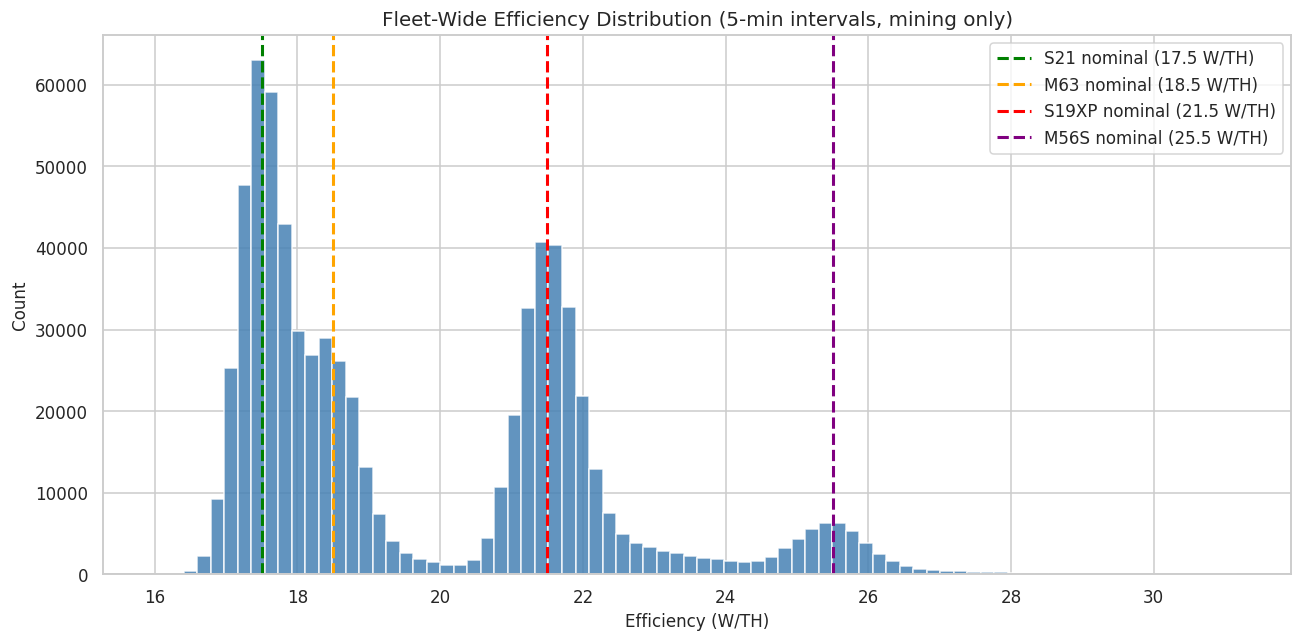

Fleet median efficiency: 18.65 W/TH
Fleet mean efficiency:   19.75 W/TH


In [4]:
# 2a. Distribution of efficiency_wth across the fleet
fig, ax = plt.subplots(figsize=(12, 6))
df_mining['efficiency_wth'].dropna().hist(bins=80, ax=ax, color='steelblue', edgecolor='white', alpha=0.85)

# Add vertical lines for each model's nominal efficiency
colors_model = {'S21': 'green', 'S19XP': 'red', 'M63': 'orange', 'M56S': 'purple'}
for model in registry.model.unique():
    nom = registry.loc[registry.model == model, 'nominal_efficiency_wth'].iloc[0]
    ax.axvline(nom, color=colors_model.get(model, 'black'), linestyle='--', linewidth=2, label=f'{model} nominal ({nom} W/TH)')

ax.set_xlabel('Efficiency (W/TH)')
ax.set_ylabel('Count')
ax.set_title('Fleet-Wide Efficiency Distribution (5-min intervals, mining only)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fleet median efficiency: {df_mining['efficiency_wth'].median():.2f} W/TH")
print(f"Fleet mean efficiency:   {df_mining['efficiency_wth'].mean():.2f} W/TH")

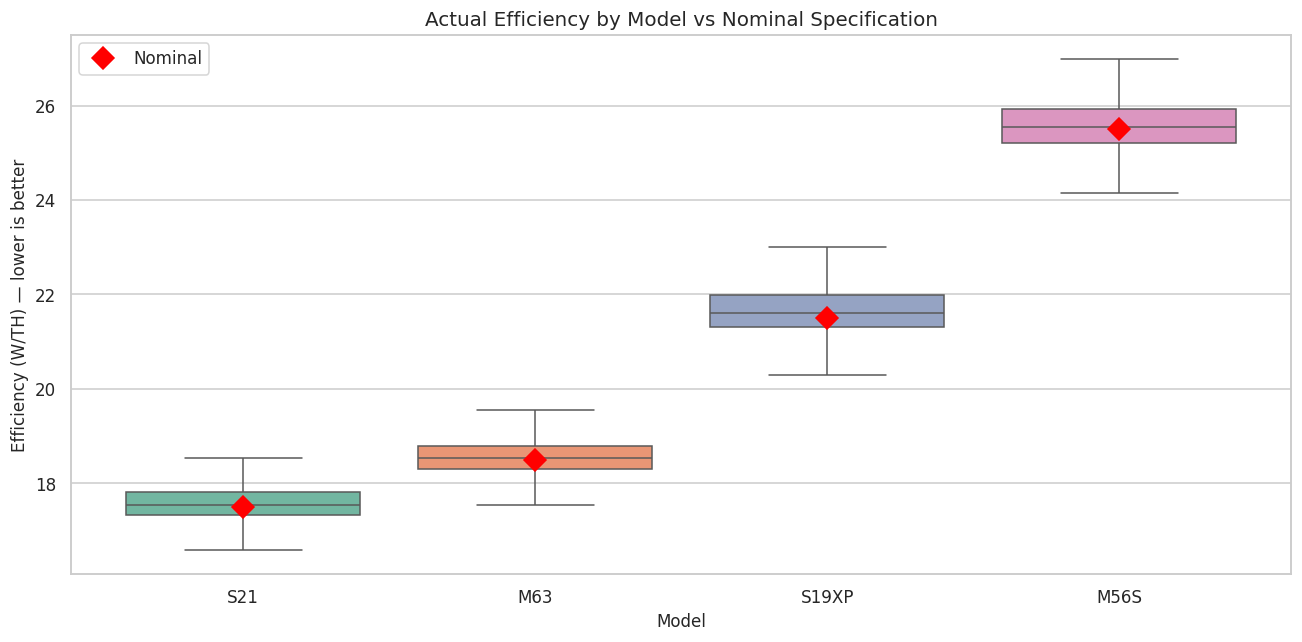

In [5]:
# 2b. Efficiency by model — box plot comparing actual vs nominal
fig, ax = plt.subplots(figsize=(12, 6))

model_order = registry.groupby('model')['nominal_efficiency_wth'].first().sort_values().index.tolist()
sns.boxplot(data=df_mining, x='model', y='efficiency_wth', order=model_order, ax=ax,
            showfliers=False, palette='Set2')

# Overlay nominal efficiency as red diamonds
for i, model in enumerate(model_order):
    nom = registry.loc[registry.model == model, 'nominal_efficiency_wth'].iloc[0]
    ax.plot(i, nom, 'D', color='red', markersize=10, zorder=5, label='Nominal' if i == 0 else '')

ax.set_xlabel('Model')
ax.set_ylabel('Efficiency (W/TH) — lower is better')
ax.set_title('Actual Efficiency by Model vs Nominal Specification')
ax.legend()
plt.tight_layout()
plt.show()

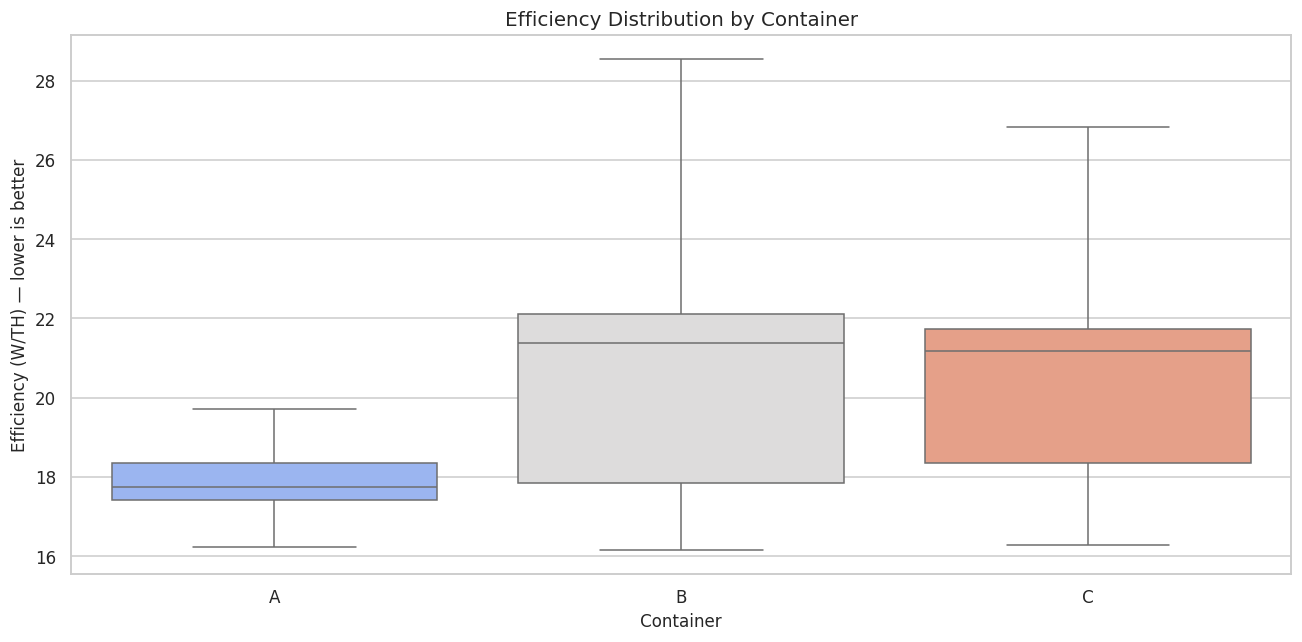


Mean efficiency by container:
            mean  median   std
container                     
A          17.87   17.74  0.59
B          21.02   21.39  2.85
C          20.37   21.17  2.07


In [6]:
# 2c. Efficiency by container
fig, ax = plt.subplots(figsize=(12, 6))

container_order = sorted(df_mining['container'].unique())
sns.boxplot(data=df_mining, x='container', y='efficiency_wth', order=container_order,
            ax=ax, showfliers=False, palette='coolwarm')

ax.set_xlabel('Container')
ax.set_ylabel('Efficiency (W/TH) — lower is better')
ax.set_title('Efficiency Distribution by Container')
plt.tight_layout()
plt.show()

# Summary stats per container
print('\nMean efficiency by container:')
print(df_mining.groupby('container')['efficiency_wth'].agg(['mean', 'median', 'std']).round(2))

---
## 3. Efficiency Gap Analysis

The **efficiency gap** measures how much worse each miner operates compared to its nominal spec.  
`gap = actual_efficiency - nominal_efficiency`  
A positive gap means the miner uses more watts per TH than expected.

In [7]:
# Per-miner mean efficiency and gap
miner_stats = df_mining.groupby('miner_id').agg(
    container=('container', 'first'),
    model=('model', 'first'),
    mean_efficiency=('efficiency_wth', 'mean'),
    median_efficiency=('efficiency_wth', 'median'),
    nominal_efficiency=('nominal_efficiency_wth', 'first'),
    nominal_hashrate=('nominal_hashrate_th', 'first'),
    mean_hashrate=('hashrate_th_5m', 'mean'),
    mean_power=('power_w', 'mean'),
    mean_elec_rate=('electricity_rate_usd_kwh', 'mean'),
    n_obs=('efficiency_wth', 'count')
).reset_index()

miner_stats['efficiency_gap'] = miner_stats['mean_efficiency'] - miner_stats['nominal_efficiency']
miner_stats['gap_pct'] = (miner_stats['efficiency_gap'] / miner_stats['nominal_efficiency'] * 100)

print(f'Miners with positive gap (worse than spec): {(miner_stats.efficiency_gap > 0).sum()} / {len(miner_stats)}')
print(f'Mean efficiency gap: {miner_stats.efficiency_gap.mean():.2f} W/TH ({miner_stats.gap_pct.mean():.1f}%)')
miner_stats.sort_values('efficiency_gap', ascending=False).head(10)

Miners with positive gap (worse than spec): 180 / 180
Mean efficiency gap: 0.20 W/TH (1.0%)


,miner_id,container,model,mean_efficiency,median_efficiency,nominal_efficiency,nominal_hashrate,mean_hashrate,mean_power,mean_elec_rate,n_obs,efficiency_gap,gap_pct
144,MNR-0145,C,S19XP,24.868847,25.03,21.5,140,135.106066,3357.482310,0.050925,3991,3.368847,15.669058
64,MNR-0065,B,S19XP,23.915534,23.98,21.5,140,144.845446,3462.737519,0.050998,3990,2.415534,11.235041
169,MNR-0170,C,S21,18.984321,19.00,17.5,200,180.185145,3413.153860,0.050998,3990,1.484321,8.481833
6,MNR-0007,A,S21,18.505662,18.49,17.5,200,203.761104,3769.764461,0.050998,4004,1.005662,5.746639
97,MNR-0098,B,S21,18.396870,18.38,17.5,200,179.783388,3303.928117,0.050998,3994,0.896870,5.124973
129,MNR-0130,C,S19XP,21.863473,21.62,21.5,140,137.176994,2995.324467,0.050713,3985,0.363473,1.690572
120,MNR-0121,C,S19XP,21.837247,21.64,21.5,140,133.266211,2906.210285,0.050998,3996,0.337247,1.568592
137,MNR-0138,C,S19XP,21.837104,21.63,21.5,140,139.413046,3040.330210,0.050998,4002,0.337104,1.567925
135,MNR-0136,C,S19XP,21.835409,21.63,21.5,140,139.478901,3041.614100,0.050998,3993,0.335409,1.560044
138,MNR-0139,C,S19XP,21.834125,21.63,21.5,140,142.160514,3099.809378,0.050973,3988,0.334125,1.554069


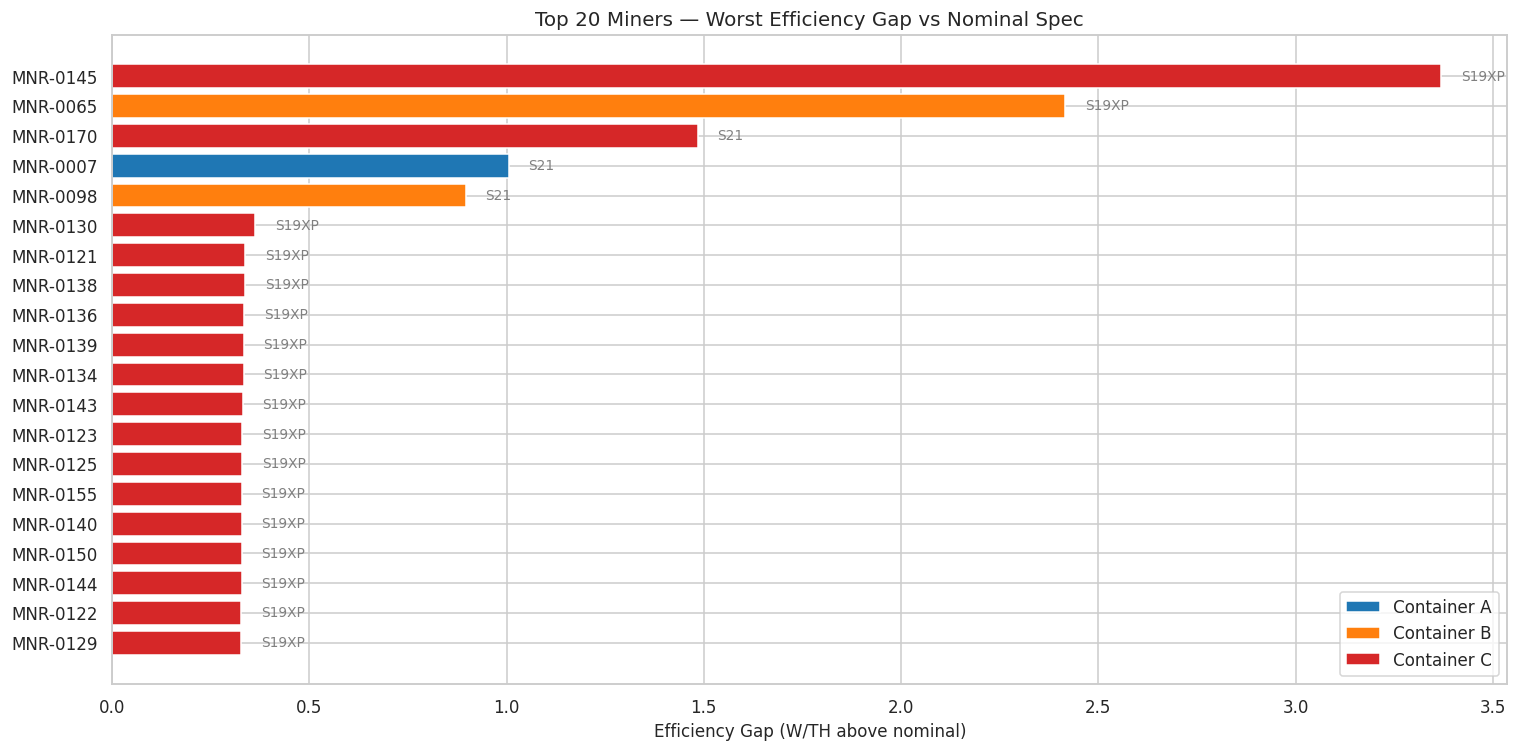

In [8]:
# Top 20 worst efficiency gaps (bar chart)
top20 = miner_stats.nlargest(20, 'efficiency_gap')

fig, ax = plt.subplots(figsize=(14, 7))
colors = top20['container'].map({'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#d62728'}).values
bars = ax.barh(top20['miner_id'], top20['efficiency_gap'], color=colors, edgecolor='white')

# Add model labels at end of bars
for bar, model in zip(bars, top20['model']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            model, va='center', fontsize=9, color='gray')

ax.set_xlabel('Efficiency Gap (W/TH above nominal)')
ax.set_title('Top 20 Miners — Worst Efficiency Gap vs Nominal Spec')
ax.invert_yaxis()

# Legend for container colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='Container A'),
                   Patch(facecolor='#ff7f0e', label='Container B'),
                   Patch(facecolor='#d62728', label='Container C')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

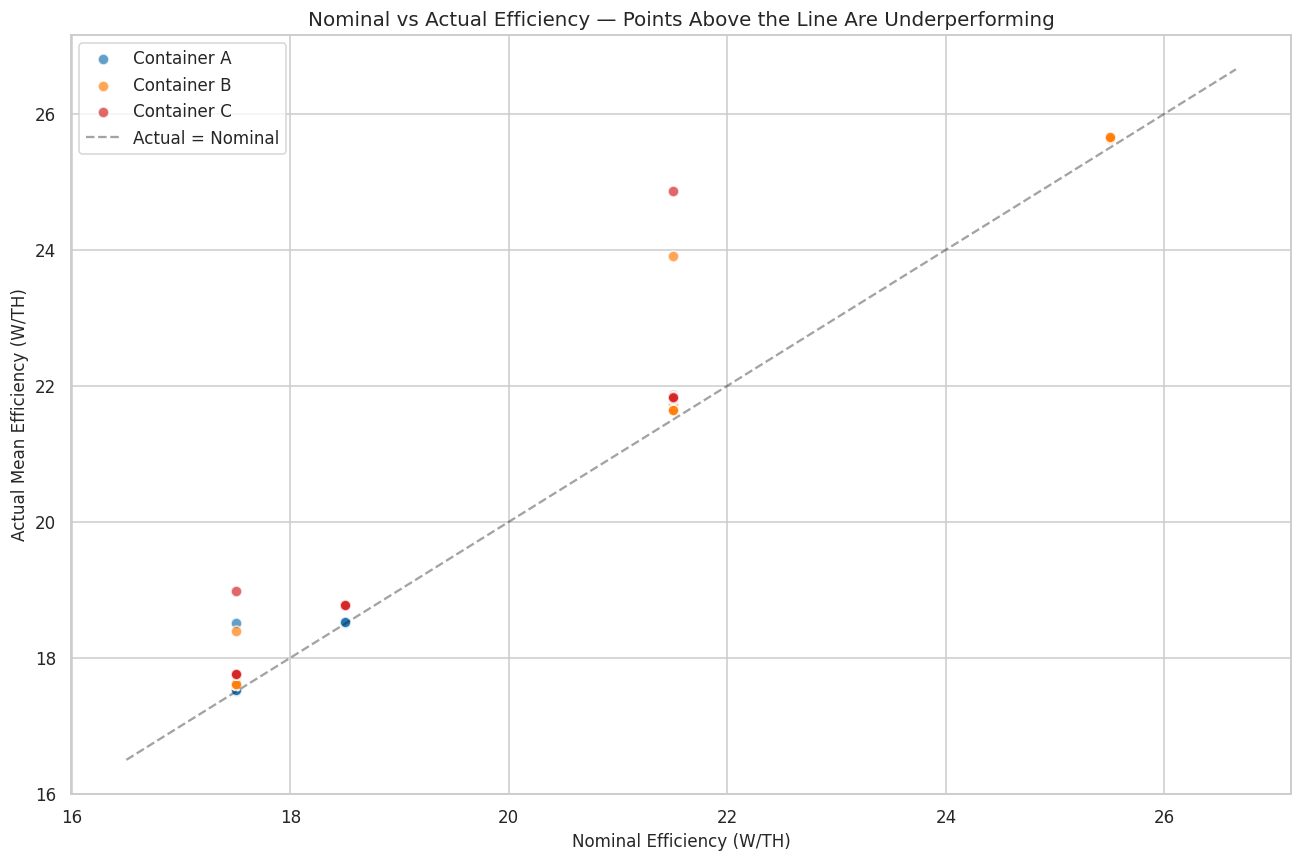

In [9]:
# Scatter: nominal vs actual efficiency, colored by container
fig, ax = plt.subplots(figsize=(12, 8))

container_colors = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#d62728'}
for container in sorted(miner_stats['container'].unique()):
    mask = miner_stats['container'] == container
    ax.scatter(miner_stats.loc[mask, 'nominal_efficiency'],
               miner_stats.loc[mask, 'mean_efficiency'],
               c=container_colors[container], label=f'Container {container}',
               alpha=0.7, s=50, edgecolor='white')

# Perfect line (actual == nominal)
lims = [miner_stats['nominal_efficiency'].min() - 1, miner_stats['mean_efficiency'].max() + 1]
ax.plot(lims, lims, 'k--', alpha=0.4, label='Actual = Nominal')

ax.set_xlabel('Nominal Efficiency (W/TH)')
ax.set_ylabel('Actual Mean Efficiency (W/TH)')
ax.set_title('Nominal vs Actual Efficiency — Points Above the Line Are Underperforming')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Waste Quantification in Dollars

We estimate the excess energy cost for each miner by computing how much extra power it draws beyond what the nominal spec predicts for the hashrate it actually delivers:

```
excess_power_w = (actual_efficiency - nominal_efficiency) * actual_hashrate
excess_cost_per_hour = excess_power_w / 1000 * electricity_rate
```

In [10]:
# Compute waste per 5-min observation
df_mining = df_mining.copy()
df_mining['excess_power_w'] = (df_mining['efficiency_wth'] - df_mining['nominal_efficiency_wth']) * df_mining['hashrate_th_5m']
df_mining['excess_cost_per_hour'] = df_mining['excess_power_w'] / 1000.0 * df_mining['electricity_rate_usd_kwh']

# Each observation covers 5 minutes = 1/12 hour
df_mining['excess_cost_5min'] = df_mining['excess_cost_per_hour'] / 12.0

total_waste_14d = df_mining['excess_cost_5min'].sum()
print(f'Total excess energy cost over 14 days: ${total_waste_14d:,.2f}')
print(f'Average daily waste: ${total_waste_14d / 14:,.2f}/day')
print(f'Projected monthly waste (30 days): ${total_waste_14d / 14 * 30:,.2f}/month')

Total excess energy cost over 14 days: $104.98
Average daily waste: $7.50/day
Projected monthly waste (30 days): $224.96/month


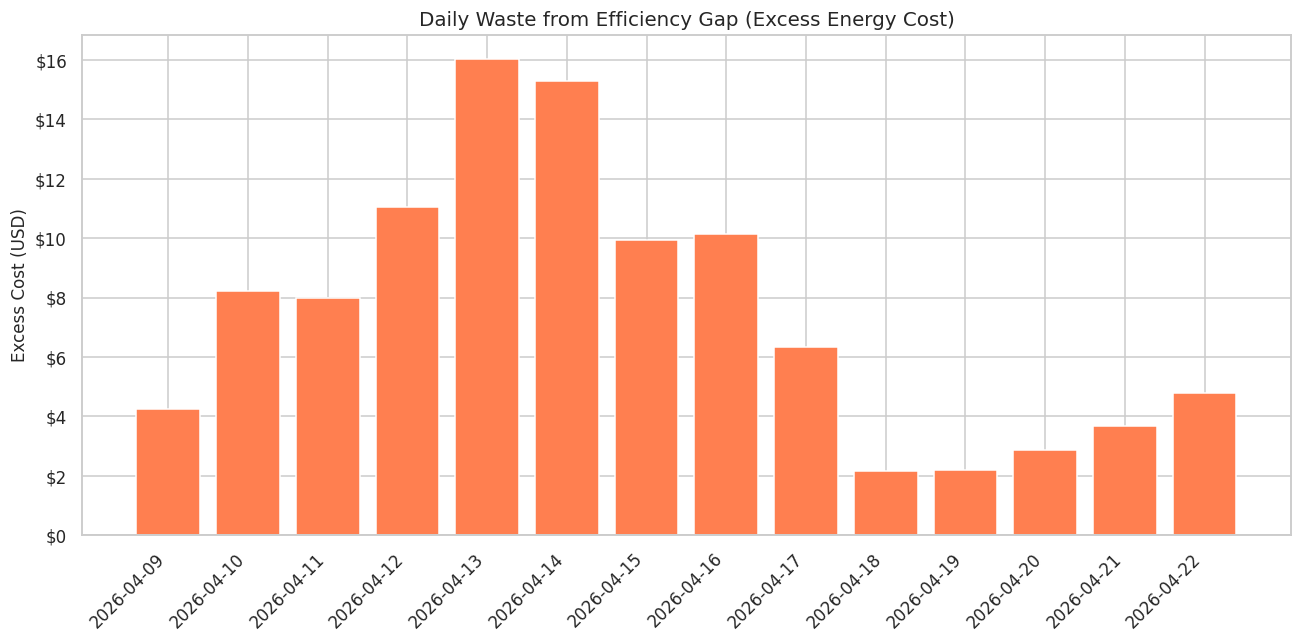

In [11]:
# Waste per day
daily_waste = df_mining.groupby('date')['excess_cost_5min'].sum().reset_index()
daily_waste.columns = ['date', 'daily_waste_usd']

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(daily_waste)), daily_waste['daily_waste_usd'], color='coral', edgecolor='white')
ax.set_xticks(range(len(daily_waste)))
ax.set_xticklabels([str(d) for d in daily_waste['date']], rotation=45, ha='right')
ax.set_ylabel('Excess Cost (USD)')
ax.set_title('Daily Waste from Efficiency Gap (Excess Energy Cost)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [12]:
# Waste per container
container_waste = df_mining.groupby('container')['excess_cost_5min'].sum().reset_index()
container_waste.columns = ['container', 'total_waste_14d']
container_waste['daily_avg'] = container_waste['total_waste_14d'] / 14
container_waste['monthly_proj'] = container_waste['daily_avg'] * 30

print('Waste by Container (14-day period):')
print(container_waste.to_string(index=False))
print()

# Comparison statement
cw = container_waste.set_index('container')
for c1 in cw.index:
    for c2 in cw.index:
        if c1 < c2:
            diff = cw.loc[c2, 'monthly_proj'] - cw.loc[c1, 'monthly_proj']
            if diff > 0:
                print(f'Container {c2} wastes ${diff:,.2f}/month more than Container {c1}')
            else:
                print(f'Container {c1} wastes ${-diff:,.2f}/month more than Container {c2}')

Waste by Container (14-day period):
container  total_waste_14d  daily_avg  monthly_proj
        A         8.320055   0.594290     17.828690
        B        29.933643   2.138117     64.143520
        C        66.728039   4.766289    142.988656

Container B wastes $46.31/month more than Container A
Container C wastes $125.16/month more than Container A
Container C wastes $78.85/month more than Container B


In [13]:
# Waste per model
model_waste = df_mining.groupby('model')['excess_cost_5min'].sum().reset_index()
model_waste.columns = ['model', 'total_waste_14d']
model_waste['daily_avg'] = model_waste['total_waste_14d'] / 14
model_waste['monthly_proj'] = model_waste['daily_avg'] * 30
print('Waste by Model (14-day period):')
print(model_waste.to_string(index=False))

Waste by Model (14-day period):
model  total_waste_14d  daily_avg  monthly_proj
 M56S         4.796355   0.342597     10.277903
  M63        19.922878   1.423063     42.691882
S19XP        48.226136   3.444724    103.341721
  S21        32.036368   2.288312     68.649360


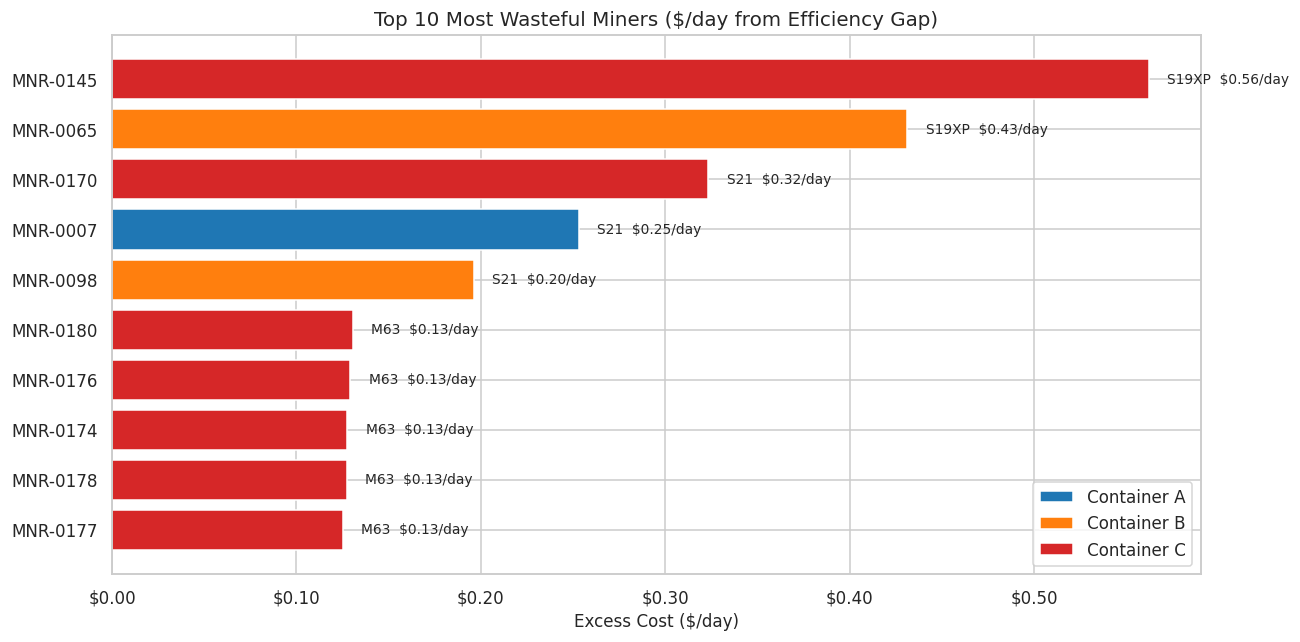

In [14]:
# Top 10 most wasteful miners — $/day
miner_waste = df_mining.groupby('miner_id').agg(
    container=('container', 'first'),
    model=('model', 'first'),
    total_waste_14d=('excess_cost_5min', 'sum')
).reset_index()
miner_waste['waste_per_day'] = miner_waste['total_waste_14d'] / 14
miner_waste_top10 = miner_waste.nlargest(10, 'waste_per_day')

fig, ax = plt.subplots(figsize=(12, 6))
colors = miner_waste_top10['container'].map({'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#d62728'}).values
bars = ax.barh(miner_waste_top10['miner_id'], miner_waste_top10['waste_per_day'],
               color=colors, edgecolor='white')

for bar, model, val in zip(bars, miner_waste_top10['model'], miner_waste_top10['waste_per_day']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{model}  ${val:.2f}/day', va='center', fontsize=9)

ax.set_xlabel('Excess Cost ($/day)')
ax.set_title('Top 10 Most Wasteful Miners ($/day from Efficiency Gap)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f}'))

legend_elements = [Patch(facecolor='#1f77b4', label='Container A'),
                   Patch(facecolor='#ff7f0e', label='Container B'),
                   Patch(facecolor='#d62728', label='Container C')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

---
## 5. Efficiency Trends Over Time

We look at daily efficiency trends to spot miners that are **degrading** (efficiency getting worse over the observation window).

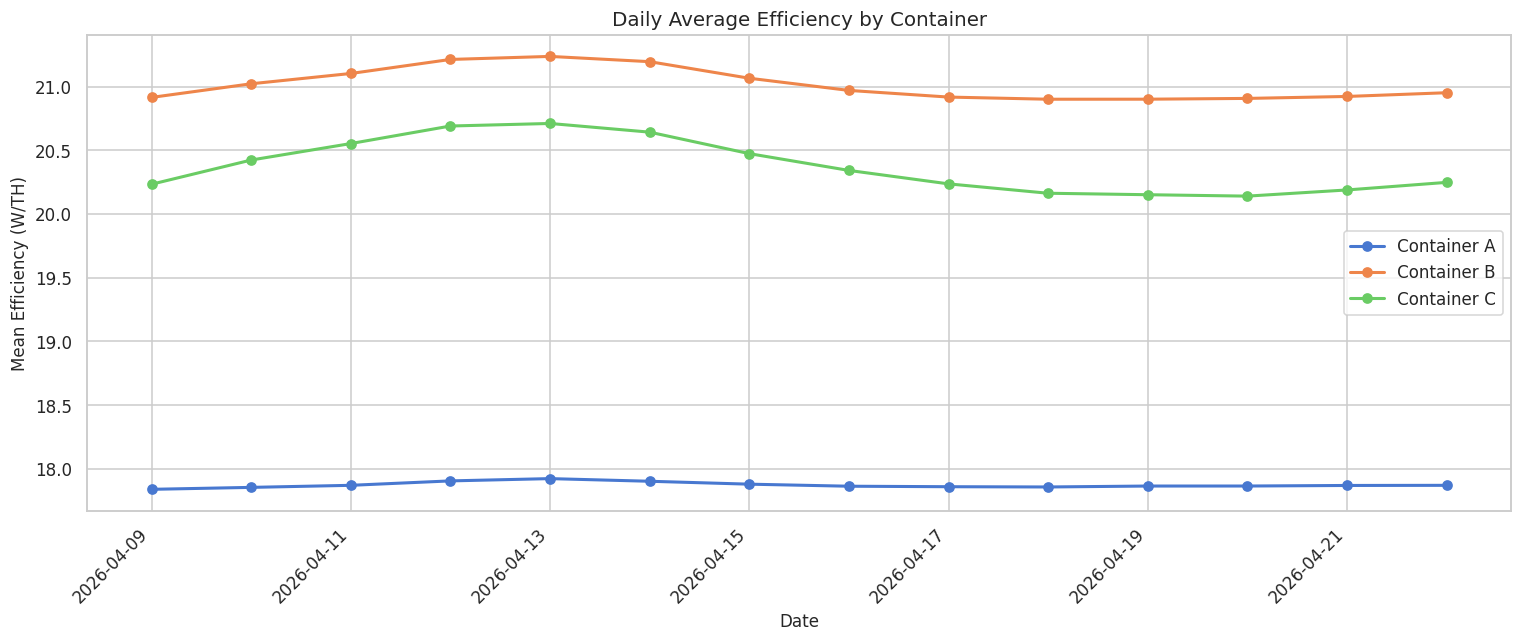

In [15]:
# 5a. Daily average efficiency per container
daily_eff_container = df_mining.groupby(['date', 'container'])['efficiency_wth'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for container in sorted(daily_eff_container['container'].unique()):
    subset = daily_eff_container[daily_eff_container['container'] == container]
    ax.plot(subset['date'], subset['efficiency_wth'], marker='o', linewidth=2, label=f'Container {container}')

ax.set_xlabel('Date')
ax.set_ylabel('Mean Efficiency (W/TH)')
ax.set_title('Daily Average Efficiency by Container')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# 5b. Linear regression on daily efficiency per miner
# For each miner, fit efficiency ~ day_number and capture slope + p-value
daily_eff_miner = df_mining.groupby(['date', 'miner_id']).agg(
    container=('container', 'first'),
    model=('model', 'first'),
    mean_eff=('efficiency_wth', 'mean')
).reset_index()

# Convert date to day number
min_date = daily_eff_miner['date'].min()
daily_eff_miner['day_num'] = (daily_eff_miner['date'] - min_date).apply(lambda x: x.days)

trend_results = []
for miner_id, grp in daily_eff_miner.groupby('miner_id'):
    if len(grp) < 5:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(grp['day_num'], grp['mean_eff'])
    trend_results.append({
        'miner_id': miner_id,
        'container': grp['container'].iloc[0],
        'model': grp['model'].iloc[0],
        'slope_wth_per_day': slope,
        'p_value': p_value,
        'r_squared': r_value**2
    })

trends = pd.DataFrame(trend_results)
print(f'Miners analyzed: {len(trends)}')
print(f'Miners with positive slope (degrading): {(trends.slope_wth_per_day > 0).sum()}')
print(f'Miners with negative slope (improving): {(trends.slope_wth_per_day < 0).sum()}')

Miners analyzed: 180
Miners with positive slope (degrading): 6
Miners with negative slope (improving): 174


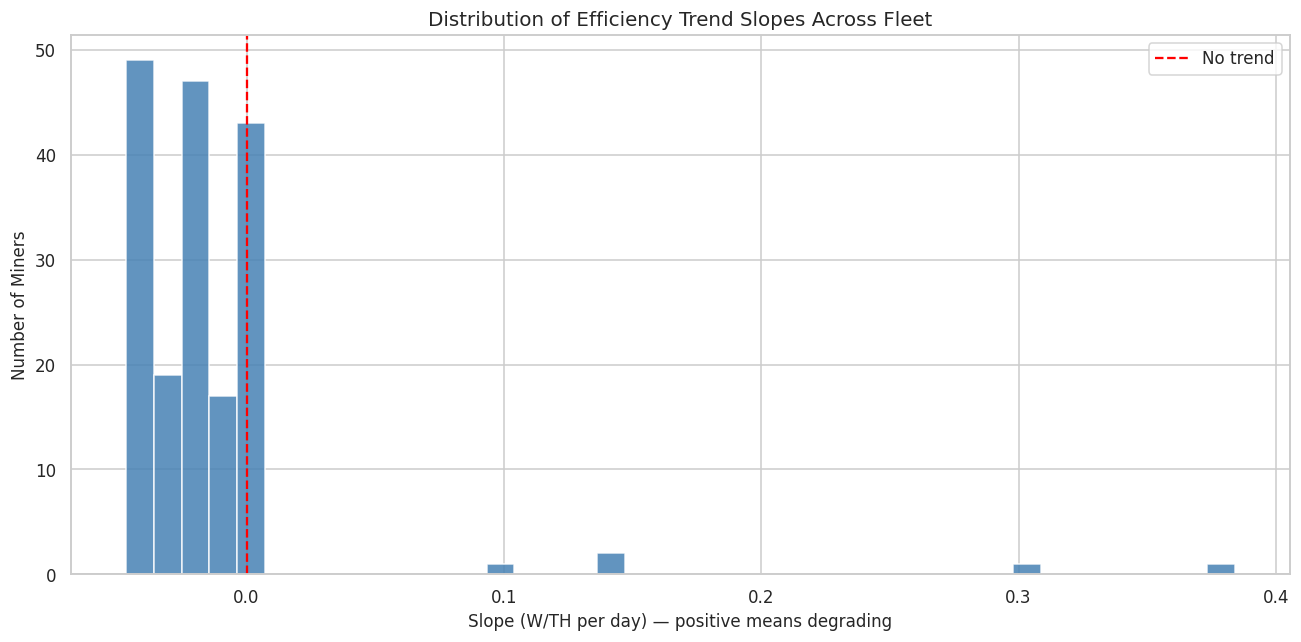

In [17]:
# 5c. Distribution of efficiency slopes
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(trends['slope_wth_per_day'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='No trend')
ax.set_xlabel('Slope (W/TH per day) — positive means degrading')
ax.set_ylabel('Number of Miners')
ax.set_title('Distribution of Efficiency Trend Slopes Across Fleet')
ax.legend()
plt.tight_layout()
plt.show()

Miners with statistically significant degradation (p < 0.05): 5

Top degrading miners:


,miner_id,container,model,slope_wth_per_day,p_value,r_squared
144,MNR-0145,C,S19XP,0.3840,0.0,0.9847
64,MNR-0065,B,S19XP,0.2999,0.0,0.9925
169,MNR-0170,C,S21,0.1439,0.0,0.9414
6,MNR-0007,A,S21,0.1394,0.0,0.9969
97,MNR-0098,B,S21,0.0945,0.0,0.9445


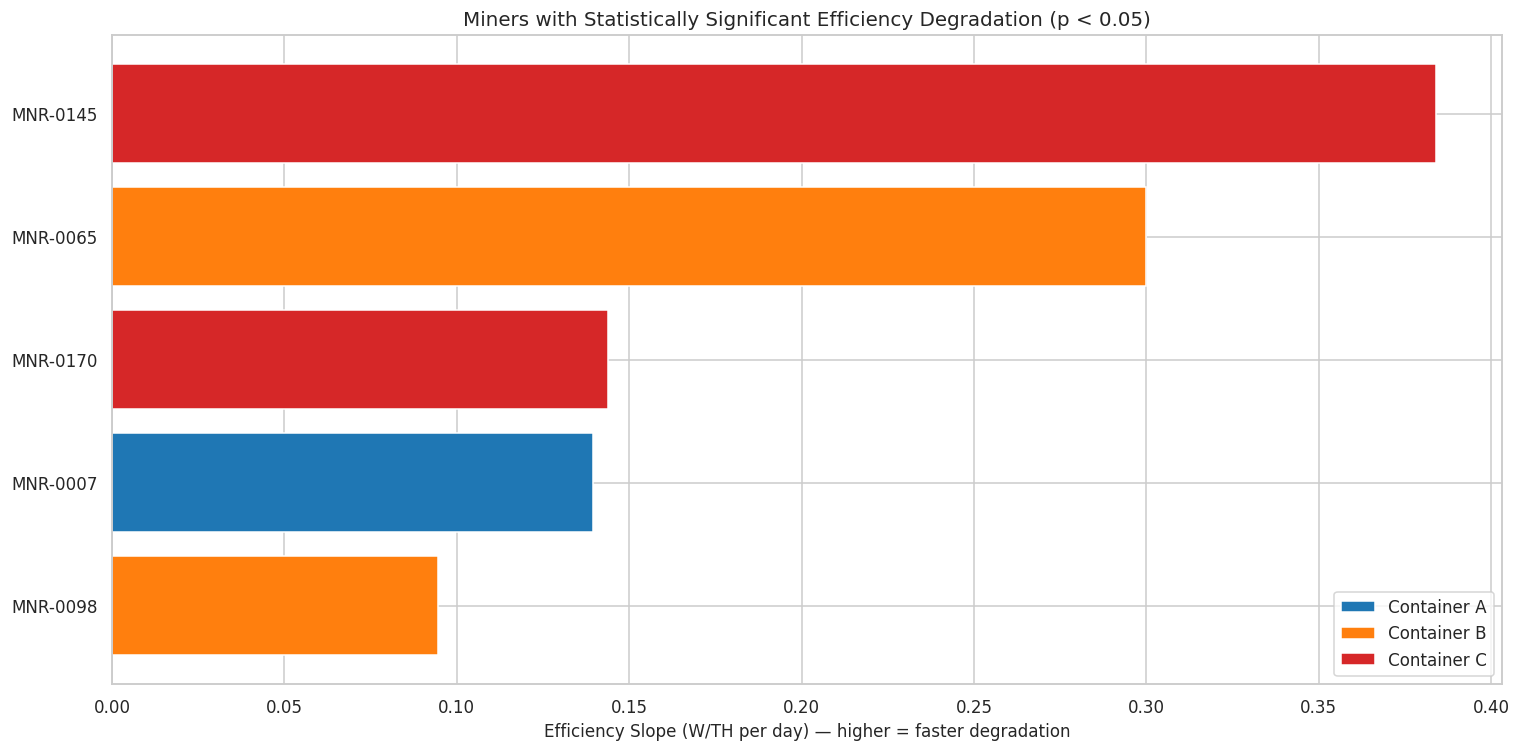

In [18]:
# 5d. Flag miners with statistically significant DEGRADATION (slope > 0, p < 0.05)
degrading = trends[(trends['slope_wth_per_day'] > 0) & (trends['p_value'] < 0.05)].copy()
degrading = degrading.sort_values('slope_wth_per_day', ascending=False)

print(f'Miners with statistically significant degradation (p < 0.05): {len(degrading)}')
if len(degrading) > 0:
    print('\nTop degrading miners:')
    display(degrading.head(20).round(4))

    # Bar chart of degrading miners
    plot_df = degrading.head(20)
    fig, ax = plt.subplots(figsize=(14, 7))
    colors = plot_df['container'].map({'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#d62728'}).values
    ax.barh(plot_df['miner_id'], plot_df['slope_wth_per_day'], color=colors, edgecolor='white')
    ax.set_xlabel('Efficiency Slope (W/TH per day) — higher = faster degradation')
    ax.set_title('Miners with Statistically Significant Efficiency Degradation (p < 0.05)')
    ax.invert_yaxis()
    legend_elements = [Patch(facecolor='#1f77b4', label='Container A'),
                       Patch(facecolor='#ff7f0e', label='Container B'),
                       Patch(facecolor='#d62728', label='Container C')]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('No miners show statistically significant degradation in this 14-day window.')

---
## 6. Hash Rate vs Nominal Performance

How well is each miner delivering its nameplate hashrate?

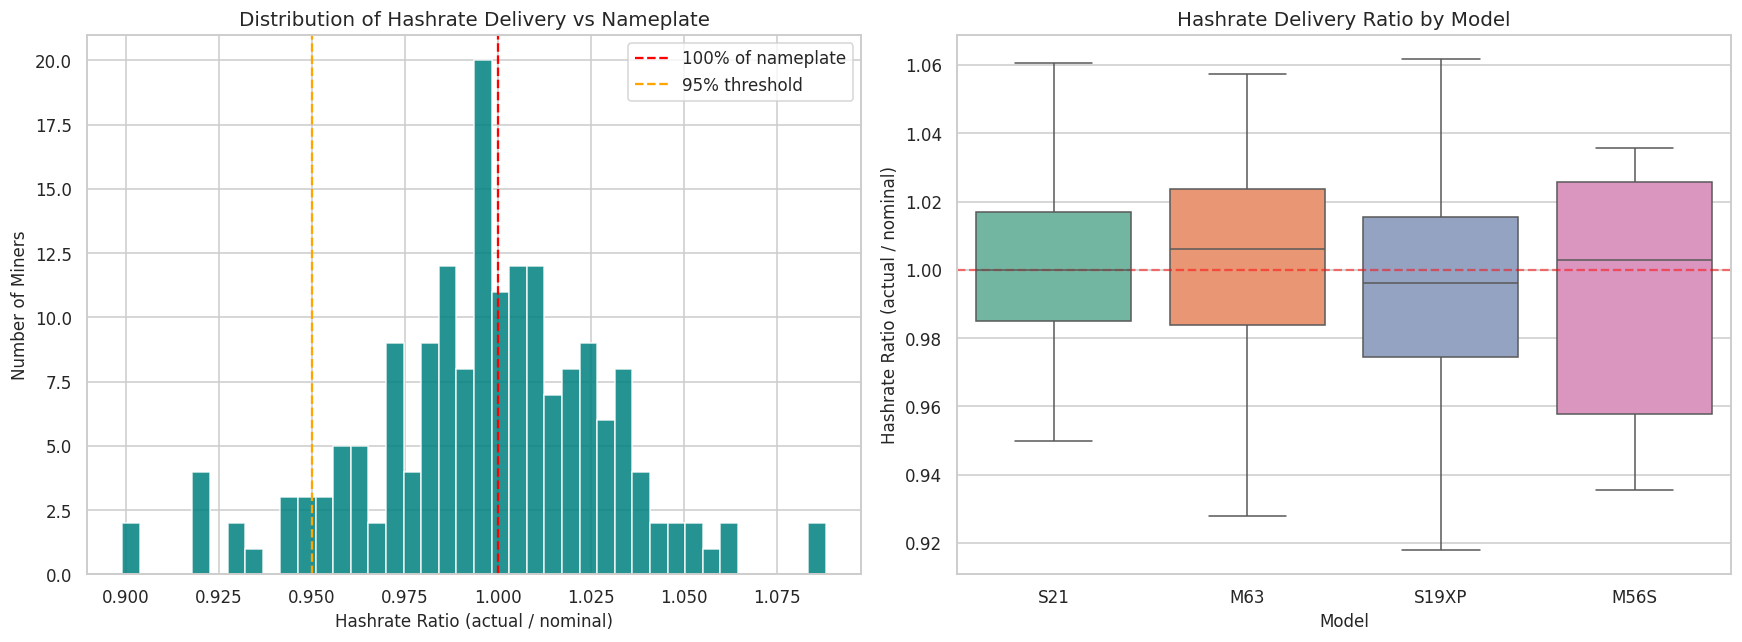


Miners operating below 95% of nameplate hashrate: 14
miner_id container model  mean_hashrate  nominal_hashrate  hashrate_ratio
MNR-0098         B   S21     179.783388               200        0.898917
MNR-0170         C   S21     180.185145               200        0.900926
MNR-0122         C S19XP     128.519119               140        0.917994
MNR-0134         C S19XP     128.698005               140        0.919271
MNR-0017         A   S21     184.109416               200        0.920547
MNR-0143         C S19XP     129.094018               140        0.922100
MNR-0055         A   M63     361.925949               390        0.928015
MNR-0105         B   S21     186.295160               200        0.931476
MNR-0114         B  M56S     198.351713               212        0.935621
MNR-0087         B S19XP     131.932342               140        0.942374
MNR-0042         A   M63     368.077647               390        0.943789
MNR-0112         B  M56S     200.580748               212 

In [19]:
# Per-miner hashrate ratio (actual / nominal)
miner_stats['hashrate_ratio'] = miner_stats['mean_hashrate'] / miner_stats['nominal_hashrate']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of hashrate ratio
axes[0].hist(miner_stats['hashrate_ratio'], bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='100% of nameplate')
axes[0].axvline(0.95, color='orange', linestyle='--', linewidth=1.5, label='95% threshold')
axes[0].set_xlabel('Hashrate Ratio (actual / nominal)')
axes[0].set_ylabel('Number of Miners')
axes[0].set_title('Distribution of Hashrate Delivery vs Nameplate')
axes[0].legend()

# Box plot by model
sns.boxplot(data=miner_stats, x='model', y='hashrate_ratio', order=model_order,
            ax=axes[1], palette='Set2', showfliers=False)
axes[1].axhline(1.0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Hashrate Ratio (actual / nominal)')
axes[1].set_title('Hashrate Delivery Ratio by Model')

plt.tight_layout()
plt.show()

# Flag miners significantly below nameplate (< 95%)
underperformers = miner_stats[miner_stats['hashrate_ratio'] < 0.95].sort_values('hashrate_ratio')
print(f'\nMiners operating below 95% of nameplate hashrate: {len(underperformers)}')
if len(underperformers) > 0:
    print(underperformers[['miner_id', 'container', 'model', 'mean_hashrate', 'nominal_hashrate', 'hashrate_ratio']].to_string(index=False))

---
## 7. Rejected Share Analysis

Rejected and stale shares represent wasted computational work (and thus wasted electricity).

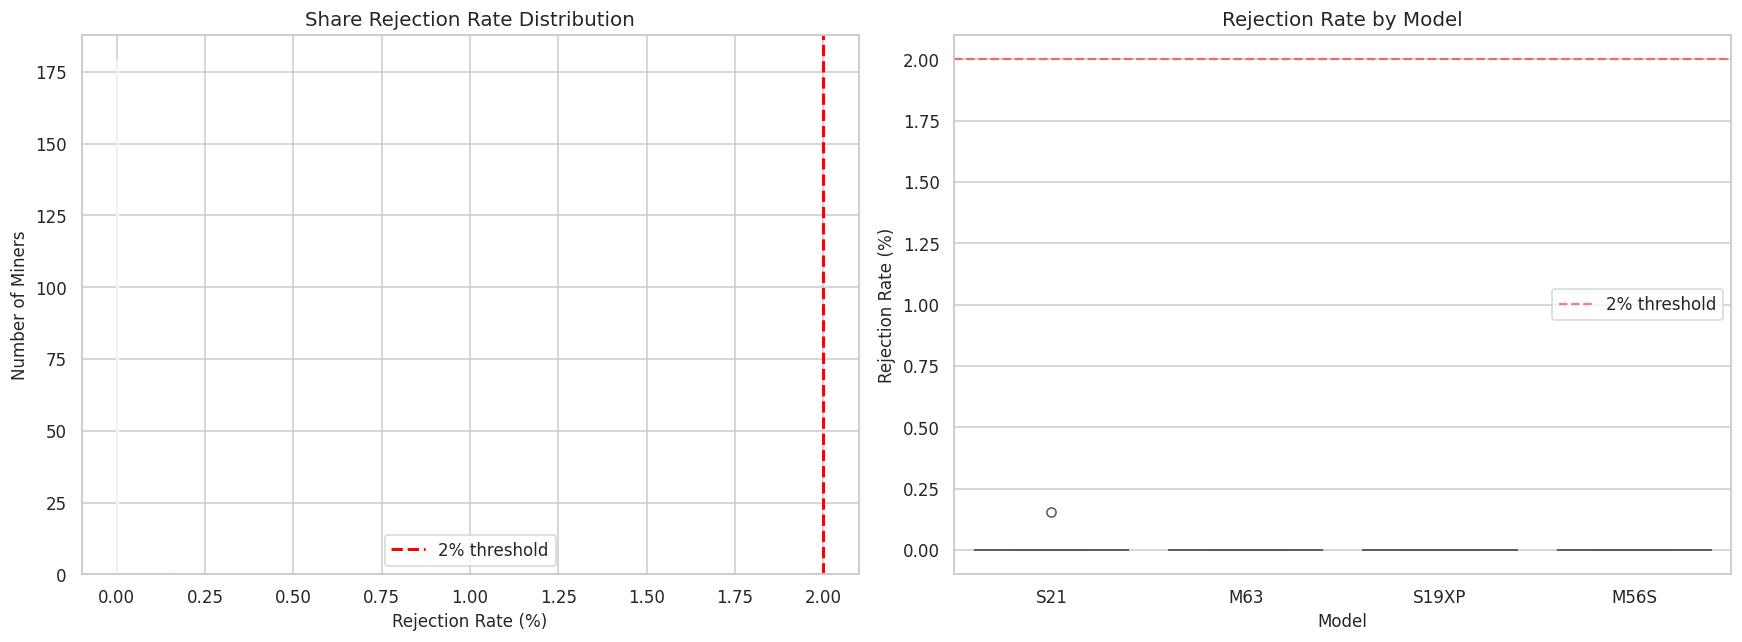

Miners above 2% rejection rate: 0


In [20]:
# Compute rejection rate per miner
shares = df_mining.groupby('miner_id').agg(
    container=('container', 'first'),
    model=('model', 'first'),
    accepted=('accepted_shares', 'sum'),
    rejected=('rejected_shares', 'sum'),
    stale=('stale_shares', 'sum'),
    mean_chip_temp=('chip_temp_c', 'mean'),
    mean_efficiency=('efficiency_wth', 'mean')
).reset_index()

shares['total_shares'] = shares['accepted'] + shares['rejected'] + shares['stale']
shares['rejection_rate'] = shares['rejected'] / shares['total_shares'] * 100
shares['stale_rate'] = shares['stale'] / shares['total_shares'] * 100
shares['bad_share_rate'] = (shares['rejected'] + shares['stale']) / shares['total_shares'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rejection rate distribution
axes[0].hist(shares['rejection_rate'], bins=40, color='salmon', edgecolor='white', alpha=0.85)
axes[0].axvline(2.0, color='red', linestyle='--', linewidth=2, label='2% threshold')
axes[0].set_xlabel('Rejection Rate (%)')
axes[0].set_ylabel('Number of Miners')
axes[0].set_title('Share Rejection Rate Distribution')
axes[0].legend()

# By model
sns.boxplot(data=shares, x='model', y='rejection_rate', order=model_order,
            ax=axes[1], palette='Set2', showfliers=True)
axes[1].axhline(2.0, color='red', linestyle='--', alpha=0.5, label='2% threshold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Rejection Rate (%)')
axes[1].set_title('Rejection Rate by Model')
axes[1].legend()

plt.tight_layout()
plt.show()

# Flag miners above 2%
high_reject = shares[shares['rejection_rate'] > 2.0].sort_values('rejection_rate', ascending=False)
print(f'Miners above 2% rejection rate: {len(high_reject)}')
if len(high_reject) > 0:
    print(high_reject[['miner_id', 'container', 'model', 'rejection_rate', 'stale_rate', 'mean_chip_temp']].round(2).to_string(index=False))

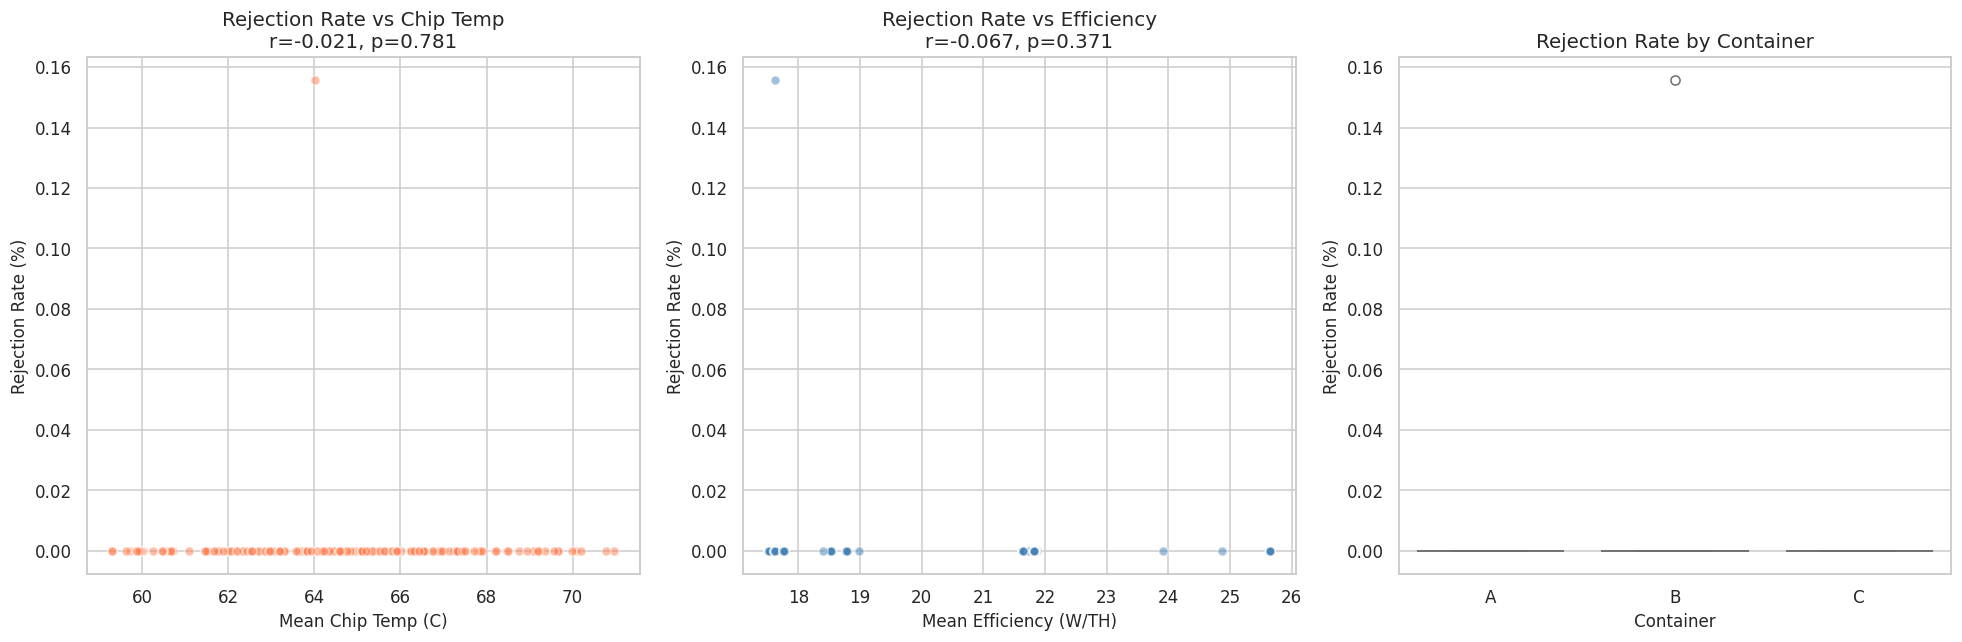

Pearson r (rejection_rate vs chip_temp):  -0.021  (p=0.7809)
Pearson r (rejection_rate vs efficiency): -0.067  (p=0.3712)


In [21]:
# Correlation: rejection rate vs temperature, efficiency, model
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Rejection rate vs chip temp
axes[0].scatter(shares['mean_chip_temp'], shares['rejection_rate'], alpha=0.5, c='coral', edgecolor='white')
r_temp, p_temp = stats.pearsonr(shares['mean_chip_temp'].dropna(), shares['rejection_rate'].dropna())
axes[0].set_xlabel('Mean Chip Temp (C)')
axes[0].set_ylabel('Rejection Rate (%)')
axes[0].set_title(f'Rejection Rate vs Chip Temp\nr={r_temp:.3f}, p={p_temp:.3f}')

# Rejection rate vs efficiency
axes[1].scatter(shares['mean_efficiency'], shares['rejection_rate'], alpha=0.5, c='steelblue', edgecolor='white')
r_eff, p_eff = stats.pearsonr(shares['mean_efficiency'].dropna(), shares['rejection_rate'].dropna())
axes[1].set_xlabel('Mean Efficiency (W/TH)')
axes[1].set_ylabel('Rejection Rate (%)')
axes[1].set_title(f'Rejection Rate vs Efficiency\nr={r_eff:.3f}, p={p_eff:.3f}')

# Rejection rate by container
sns.boxplot(data=shares, x='container', y='rejection_rate', ax=axes[2], palette='coolwarm')
axes[2].set_xlabel('Container')
axes[2].set_ylabel('Rejection Rate (%)')
axes[2].set_title('Rejection Rate by Container')

plt.tight_layout()
plt.show()

print(f'Pearson r (rejection_rate vs chip_temp):  {r_temp:.3f}  (p={p_temp:.4f})')
print(f'Pearson r (rejection_rate vs efficiency): {r_eff:.3f}  (p={p_eff:.4f})')

---
## 8. Key Findings & Recommendations

In [22]:
# Compile key metrics for the summary
daily_waste_avg = total_waste_14d / 14
monthly_waste_proj = daily_waste_avg * 30

n_degrading = len(degrading) if len(degrading) > 0 else 0
n_high_reject = len(high_reject) if len(high_reject) > 0 else 0
n_underperf = len(underperformers) if len(underperformers) > 0 else 0

worst_container = cw['monthly_proj'].idxmax()
worst_container_cost = cw['monthly_proj'].max()

# Gap stats
mean_gap = miner_stats['efficiency_gap'].mean()
worst_miner = miner_stats.loc[miner_stats['efficiency_gap'].idxmax()]

print('=' * 70)
print('KEY FINDINGS — EFFICIENCY ANALYSIS & WASTE QUANTIFICATION')
print('=' * 70)
print()
print(f'1. FLEET EFFICIENCY GAP')
print(f'   Mean gap vs nominal: {mean_gap:+.2f} W/TH across {len(miner_stats)} miners')
print(f'   Worst miner: {worst_miner["miner_id"]} ({worst_miner["model"]}, Container {worst_miner["container"]}) '
      f'at +{worst_miner["efficiency_gap"]:.2f} W/TH above spec')
print()
print(f'2. FINANCIAL IMPACT')
print(f'   Daily waste from efficiency gap:   ${daily_waste_avg:,.2f}/day')
print(f'   Projected monthly waste:           ${monthly_waste_proj:,.2f}/month')
print(f'   Worst container ({worst_container}):            ${worst_container_cost:,.2f}/month')
print()
print(f'3. DEGRADING MINERS')
print(f'   {n_degrading} miners show statistically significant efficiency degradation (p < 0.05)')
if n_degrading > 0:
    top_degrading = degrading.iloc[0]
    print(f'   Fastest degrader: {top_degrading["miner_id"]} at {top_degrading["slope_wth_per_day"]:.4f} W/TH per day')
print()
print(f'4. HASHRATE UNDER-DELIVERY')
print(f'   {n_underperf} miners below 95% of nameplate hashrate')
print()
print(f'5. REJECTED SHARES')
print(f'   {n_high_reject} miners above 2% rejection rate')
print(f'   Correlation with temperature: r={r_temp:.3f}')
print(f'   Correlation with efficiency: r={r_eff:.3f}')
print()

KEY FINDINGS — EFFICIENCY ANALYSIS & WASTE QUANTIFICATION

1. FLEET EFFICIENCY GAP
   Mean gap vs nominal: +0.20 W/TH across 180 miners
   Worst miner: MNR-0145 (S19XP, Container C) at +3.37 W/TH above spec

2. FINANCIAL IMPACT
   Daily waste from efficiency gap:   $7.50/day
   Projected monthly waste:           $224.96/month
   Worst container (C):            $142.99/month

3. DEGRADING MINERS
   5 miners show statistically significant efficiency degradation (p < 0.05)
   Fastest degrader: MNR-0145 at 0.3840 W/TH per day

4. HASHRATE UNDER-DELIVERY
   14 miners below 95% of nameplate hashrate

5. REJECTED SHARES
   0 miners above 2% rejection rate
   Correlation with temperature: r=-0.021
   Correlation with efficiency: r=-0.067



RECOMMENDATIONS — PRIORITY MATRIX


,Finding,Action,Impact,Effort,Est. Monthly Savings
0,Top 10 wasteful miners,Inspect & retune firmware/frequency on worst-g...,High,Low,$72
1,Container C highest waste,Audit cooling & airflow in Container C; check ...,High,Medium,$143
2,5 miners degrading over time,Schedule preventive maintenance; check for dus...,Medium,Medium,Prevents future losses
3,14 miners below nameplate hashrate,"Check hash boards, replace failing chips, upda...",Medium,High,Revenue uplift from restored hashrate
4,0 miners with high rejection rate,"Check network config, pool connectivity, firmw...",Low-Medium,Low,Reduced wasted compute


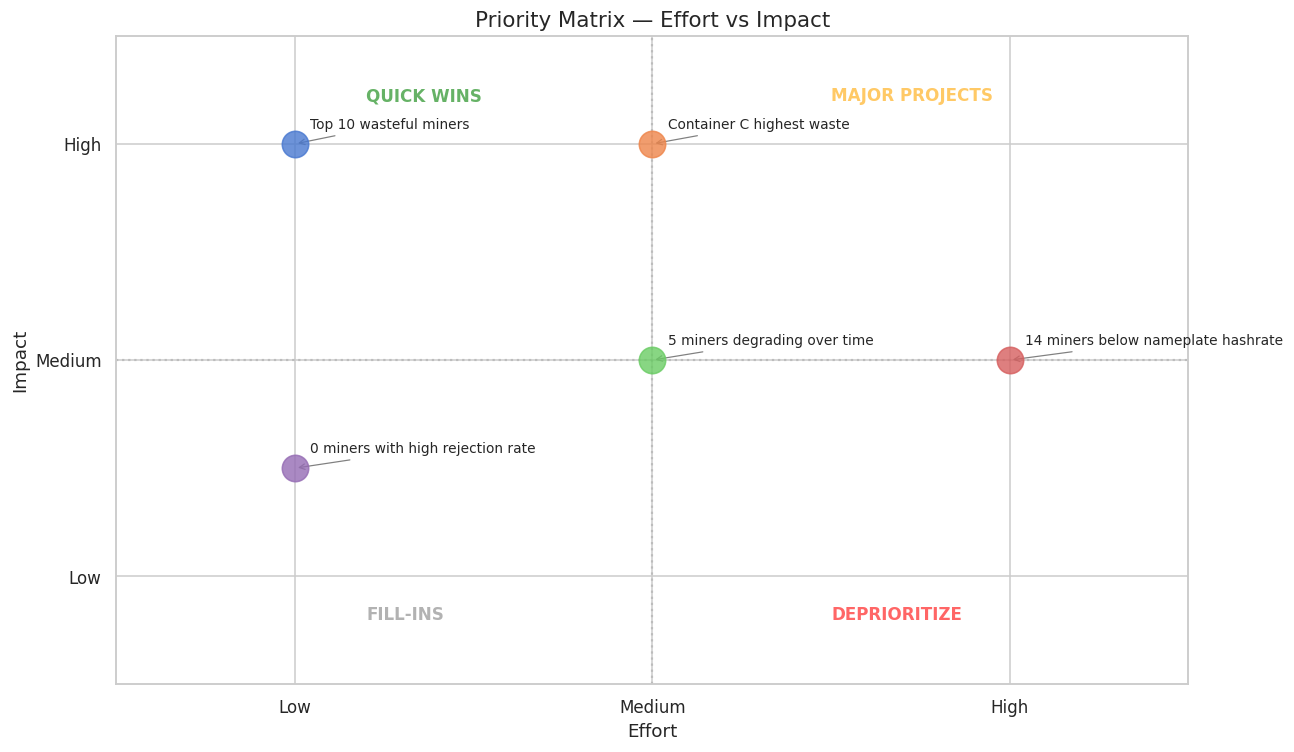

In [23]:
# Priority matrix: effort vs impact
recommendations = pd.DataFrame([
    {'Finding': 'Top 10 wasteful miners',
     'Action': 'Inspect & retune firmware/frequency on worst-gap miners',
     'Impact': 'High',
     'Effort': 'Low',
     'Est. Monthly Savings': f'${miner_waste.nlargest(10, "waste_per_day")["waste_per_day"].sum() * 30:.0f}'},
    {'Finding': f'Container {worst_container} highest waste',
     'Action': f'Audit cooling & airflow in Container {worst_container}; check inlet temps',
     'Impact': 'High',
     'Effort': 'Medium',
     'Est. Monthly Savings': f'${worst_container_cost:.0f}'},
    {'Finding': f'{n_degrading} miners degrading over time',
     'Action': 'Schedule preventive maintenance; check for dust/thermal paste degradation',
     'Impact': 'Medium',
     'Effort': 'Medium',
     'Est. Monthly Savings': 'Prevents future losses'},
    {'Finding': f'{n_underperf} miners below nameplate hashrate',
     'Action': 'Check hash boards, replace failing chips, update firmware',
     'Impact': 'Medium',
     'Effort': 'High',
     'Est. Monthly Savings': 'Revenue uplift from restored hashrate'},
    {'Finding': f'{n_high_reject} miners with high rejection rate',
     'Action': 'Check network config, pool connectivity, firmware versions',
     'Impact': 'Low-Medium',
     'Effort': 'Low',
     'Est. Monthly Savings': 'Reduced wasted compute'}
])

print('RECOMMENDATIONS — PRIORITY MATRIX')
print('=' * 70)
display(recommendations)

# Visual priority matrix
fig, ax = plt.subplots(figsize=(12, 7))
effort_map = {'Low': 1, 'Medium': 2, 'High': 3}
impact_map = {'Low': 1, 'Low-Medium': 1.5, 'Medium': 2, 'High': 3}

for _, row in recommendations.iterrows():
    x = effort_map[row['Effort']]
    y = impact_map[row['Impact']]
    ax.scatter(x, y, s=300, zorder=5, alpha=0.8)
    ax.annotate(row['Finding'], (x, y), textcoords='offset points',
                xytext=(10, 10), fontsize=9, wrap=True,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_xlim(0.5, 3.5)
ax.set_ylim(0.5, 3.5)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Effort', fontsize=12)
ax.set_ylabel('Impact', fontsize=12)
ax.set_title('Priority Matrix — Effort vs Impact', fontsize=14)

# Quadrant shading
ax.axhline(2, color='gray', linestyle=':', alpha=0.3)
ax.axvline(2, color='gray', linestyle=':', alpha=0.3)
ax.text(1.2, 3.2, 'QUICK WINS', fontsize=11, color='green', fontweight='bold', alpha=0.6)
ax.text(2.5, 3.2, 'MAJOR PROJECTS', fontsize=11, color='orange', fontweight='bold', alpha=0.6)
ax.text(1.2, 0.8, 'FILL-INS', fontsize=11, color='gray', fontweight='bold', alpha=0.6)
ax.text(2.5, 0.8, 'DEPRIORITIZE', fontsize=11, color='red', fontweight='bold', alpha=0.6)

plt.tight_layout()
plt.show()